# Abraham A. Owodunni

## Data Dictionary

Aberporth
Location: 224100E 252100N, Lat 52.139 Lon -4.570, 133 metres amsl
Estimated data is marked with a * after the value.
Missing data (more than 2 days missing in month) is marked by  ---.
Sunshine data taken from an automatic Kipp & Zonen sensor marked with a #, 
Otherwise sunshine data taken from a Campbell Stokes recorder.

This dataset contains monthly climate observations for the Aberporth weather station. Each record represents aggregated weather measurements for a given number of months tending towards decades. 

### Attributes/Variables:

- yyyy (Year) - the normal calendar year of observation. Datatype = integer.
- mm (Month) - the months of observation (months 1 - 12). Datatype = integer.
- Date - monthly date representation combining year and month by assigning the first day of each month. (This was created for easy time-series analysis). Datatype = date.
- tmax_degC (Maximum temperature) - the average monthly maximum temperature, measured in degree celcius. Datatype = float.
- tmin_degC (Minimum temperature) - the average monthly minimum temperature, measured in degree celcius. Datatype = float.
- rain_mm (Rainfall) - the monthly total rainfall recorded, measured in millimetres (mm). Datatype = float.
- sun_hours (Sunshine) - this is the monthly total number of sunshine hours recorded, measured in hours. Datatype = float.
- af_days (Air Frost Days) - this is the number of days in month with air frost, measured in days.Datatype = integer.

### About Dataset:

The dataset contains a mix of continuous, seasonal, and count-based climate variables. Each attribute was treated according to its statistical properties and data quality characteristics to ensure reliable, and valid analysis.

Attribute definitions and data quality notes are based on the accompanying Aberporth station data provided, supplemented by standard UK Met Office climate data conventions. 

### Note:

The dataset structure and attribute meanings were made to align with those used in UK Meteoroligical Office MIDAS monthly climate records.

## Import Necessary Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import calendar
import matplotlib.colors as colors
import matplotlib.cm as cm

## Read CSV Dataset

In [2]:
# Read the file
df = pd.read_csv("DataOnly.csv")
# print the first five lines (the head) of the dataframe
df.head()

,yyyy,mm,tmax degC,tmin degC,af days,rain mm,sun hours
0,1941,1,NaN,NaN,NaN,74.7,NaN
1,1941,2,NaN,NaN,NaN,69.1,NaN
2,1941,3,NaN,NaN,NaN,76.2,NaN
3,1941,4,NaN,NaN,NaN,33.7,NaN
4,1941,5,NaN,NaN,NaN,51.3,NaN


In [3]:
df['yyyy'].unique()

array([1941, 1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951,
       1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962,
       1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973,
       1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984,
       1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995,
       1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017,
       2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025], dtype=int64)

In [4]:
# Get the shape of the dataset
df.shape

(1020, 7)

In [5]:
#Get info about the dataset- the datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   yyyy       1020 non-null   int64  
 1   mm         1020 non-null   int64  
 2   tmax degC  1002 non-null   float64
 3   tmin degC  1008 non-null   float64
 4   af days    828 non-null    float64
 5   rain mm    1020 non-null   float64
 6   sun hours  1006 non-null   object 
dtypes: float64(4), int64(2), object(1)
memory usage: 55.9+ KB


In [6]:
# a brief description of the dataset
df.describe(include = 'all')

,yyyy,mm,tmax degC,tmin degC,af days,rain mm,sun hours
count,1020.000000,1020.000000,1002.000000,1008.000000,828.000000,1020.000000,1006
unique,NaN,NaN,NaN,NaN,NaN,NaN,902
top,NaN,NaN,NaN,NaN,NaN,NaN,40.1
freq,NaN,NaN,NaN,NaN,NaN,NaN,4
mean,1983.000000,6.500000,12.527146,7.295337,1.461353,76.277353,NaN
std,24.547724,3.453746,4.119438,3.640671,3.230703,42.265689,NaN
min,1941.000000,1.000000,1.300000,-3.500000,0.000000,0.000000,NaN
25%,1962.000000,3.750000,9.000000,4.400000,0.000000,45.775000,NaN
50%,1983.000000,6.500000,12.500000,6.900000,0.000000,69.300000,NaN
75%,2004.000000,9.250000,16.200000,10.700000,1.000000,99.600000,NaN


In [7]:
# Check for missing values
df.isna().sum()

yyyy           0
mm             0
tmax degC     18
tmin degC     12
af days      192
rain mm        0
sun hours     14
dtype: int64

##### From above, there are 18 missing values in maximum temperature, 12 in minimum temperature, 192 in air frost day and 14 in sunshine hours

# Data Preprocessing

#### Create a datetime index (monthly)
This analysis is time-series based (weather/climatic condition), I will be analysing:

- Trends over time in temperature, sunshine, etc
- Seasonality
- Year-to-year variability

Hence, creating another feature/attribute using proper datetime index will

- Ensure correct chronological ordering
- Make plots and grouping reliable and possible

In [8]:
# Create a datetime index (monthly)
df['Date'] = pd.to_datetime(df['yyyy'].astype(str) + '-' + df['mm'].astype(str) + '-01')
df = df.set_index('Date').sort_index()
df.head()

,yyyy,mm,tmax degC,tmin degC,af days,rain mm,sun hours
Date,,,,,,,
1941-01-01,1941,1,NaN,NaN,NaN,74.7,NaN
1941-02-01,1941,2,NaN,NaN,NaN,69.1,NaN
1941-03-01,1941,3,NaN,NaN,NaN,76.2,NaN
1941-04-01,1941,4,NaN,NaN,NaN,33.7,NaN
1941-05-01,1941,5,NaN,NaN,NaN,51.3,NaN


The above was needed because the dataset is monthly, a full date was required to construct a time index. I used the first day of each month as a neutral placeholder to preserve consistent temporal spacing and without introducing assumptions about intra-month behaviour.

### Rename the columns to be readable and for easy understanding

In [9]:
# Rename the columns to be readable and analysis/easy understanding at first sight for a layman
df = df.rename(columns={
    'yyyy': 'Year',
    'mm': 'Month',
    'tmax degC': 'Max_Temperature(DegC)',
    'tmin degC': 'Min_Temperature(DegC)',
    'af days': 'Air_Frost_Days',
    'rain mm': 'Rainfall(mm)',
    'sun hours': 'Sunshine_hours'})
df.head()

,Year,Month,Max_Temperature(DegC),Min_Temperature(DegC),Air_Frost_Days,Rainfall(mm),Sunshine_hours
Date,,,,,,,
1941-01-01,1941,1,NaN,NaN,NaN,74.7,NaN
1941-02-01,1941,2,NaN,NaN,NaN,69.1,NaN
1941-03-01,1941,3,NaN,NaN,NaN,76.2,NaN
1941-04-01,1941,4,NaN,NaN,NaN,33.7,NaN
1941-05-01,1941,5,NaN,NaN,NaN,51.3,NaN


## Distribution of the Features in the Dataset

<Figure size 1020x680 with 0 Axes>

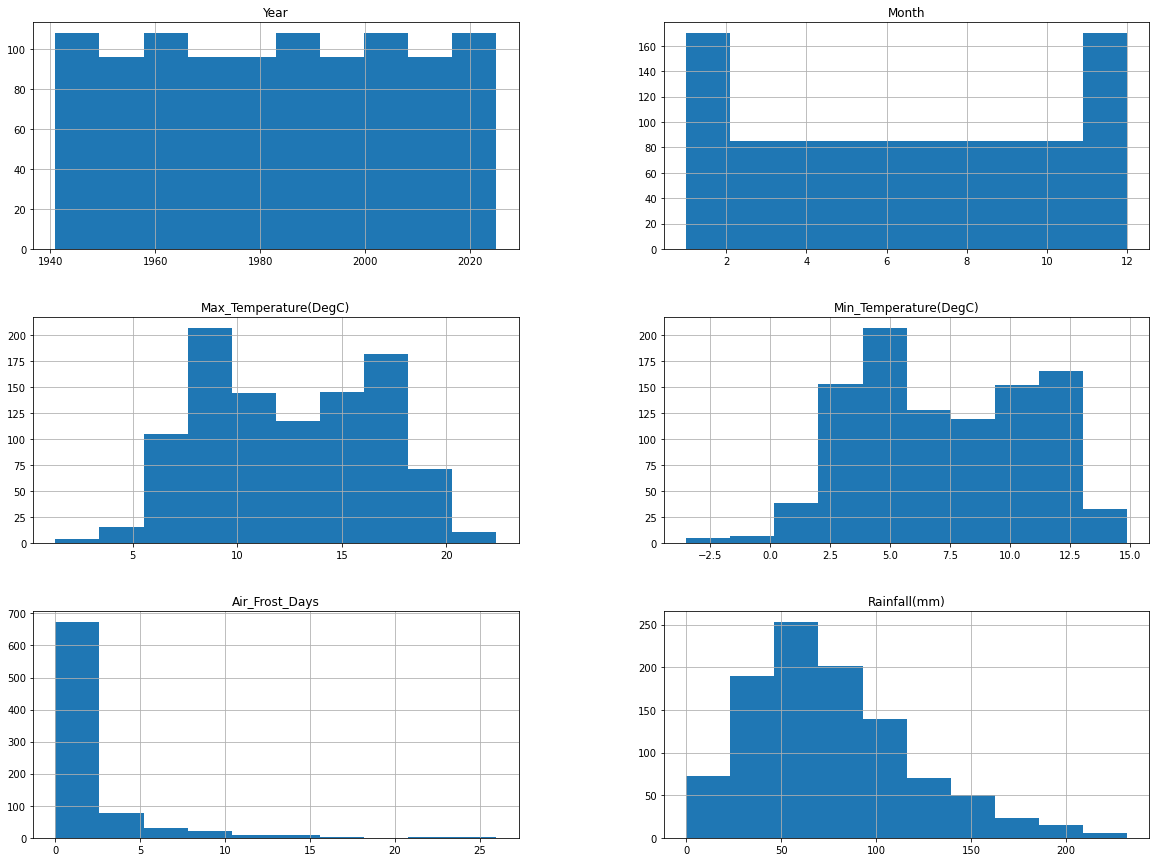

In [10]:
plt.figure(dpi = 170)
df.hist(figsize = (20, 15)) 
plt.show()

### For better viewing, months are written in words, matching each exact month's number

In [11]:
# create a column for months' names
df['Month_Name'] = pd.to_datetime(df['Month'], format='%m').dt.month_name()
df.head()

,Year,Month,Max_Temperature(DegC),Min_Temperature(DegC),Air_Frost_Days,Rainfall(mm),Sunshine_hours,Month_Name
Date,,,,,,,,
1941-01-01,1941,1,NaN,NaN,NaN,74.7,NaN,January
1941-02-01,1941,2,NaN,NaN,NaN,69.1,NaN,February
1941-03-01,1941,3,NaN,NaN,NaN,76.2,NaN,March
1941-04-01,1941,4,NaN,NaN,NaN,33.7,NaN,April
1941-05-01,1941,5,NaN,NaN,NaN,51.3,NaN,May


# Data Cleaning

### Cleaning the Temperature Columns

Maximum temperature has 18 missing values while minimum temperature has 12

Temperature is smooth and autocorrelated (values taken at usually constant intervals) over time, that is, it is gradual and cannot abruptly change from let's say 2 to 40 degrees celcius suddenly. I would use time-based interpolation to fill the missing values for smooth meteorological variables. 

Using that alone, filling the missing values with interpolation alone will not completely work - as no values before and after to fill the missing values in between/the middle (principle of interpolation will not stand). Hence, I have to combine this with backward filling. This is preferred over forward filling because no integers/values in degrees were recorded from the top of the dataset.

In [12]:
# Fill the missing values using interpolation and backward filling methods together
df['Max_Temperature(DegC)'] = (df['Max_Temperature(DegC)'].interpolate(method='time').bfill())
df['Min_Temperature(DegC)'] = (df['Min_Temperature(DegC)'].interpolate(method='time').bfill())
df.head()

,Year,Month,Max_Temperature(DegC),Min_Temperature(DegC),Air_Frost_Days,Rainfall(mm),Sunshine_hours,Month_Name
Date,,,,,,,,
1941-01-01,1941,1,5.8,2.1,NaN,74.7,NaN,January
1941-02-01,1941,2,5.8,2.1,NaN,69.1,NaN,February
1941-03-01,1941,3,5.8,2.1,NaN,76.2,NaN,March
1941-04-01,1941,4,5.8,2.1,NaN,33.7,NaN,April
1941-05-01,1941,5,5.8,2.1,NaN,51.3,NaN,May


### Cleaning the Sunshine Column

Sunshine data was cleaned with monthly median imputation because it is continuous and seasonal. Sunshine column was object datatype, sunshine hours must be converted from object to numeric due to non-numeric measurement markers given with the instruction on the dataset.

In [13]:
# check datatype
df['Sunshine_hours'].dtype

dtype('O')

In [14]:
# 1. convert attribute from object to numeric
df['Sunshine_hours'] = pd.to_numeric(df['Sunshine_hours'], errors='coerce')

# 2. clean using monthly median usinf a function
df['Sunshine_hours'] = (df.groupby(df.index.month)['Sunshine_hours'].transform(lambda x: x.fillna(x.median())))
df.head()

,Year,Month,Max_Temperature(DegC),Min_Temperature(DegC),Air_Frost_Days,Rainfall(mm),Sunshine_hours,Month_Name
Date,,,,,,,,
1941-01-01,1941,1,5.8,2.1,NaN,74.7,52.65,January
1941-02-01,1941,2,5.8,2.1,NaN,69.1,76.00,February
1941-03-01,1941,3,5.8,2.1,NaN,76.2,115.95,March
1941-04-01,1941,4,5.8,2.1,NaN,33.7,172.20,April
1941-05-01,1941,5,5.8,2.1,NaN,51.3,204.90,May


### Air Frost Days

Air Frost Days means number of days in a month where minimum temperature is less than or equal to 0°C. Hence air frost days
were not imputed due to their threshold-based nature and structural missingness in early records maybe due to incomplete daily observations.

Missing values were deliberately retained to avoid introducing artificial or misleading information for integrity of other climate variables. And I could not replace with zero (0) because it would mean there were definitely no frost days at all,  bias trends downward/bias KPI intepretation, and would make early years look warmer than they were (according to the dataset). That will be factually incorrect for many of those months, especially early years.

In [15]:
# checking if the cleaned variables/attributes (excluding air frost day) have been effected in the general dataset
df.isna().sum()

Year                       0
Month                      0
Max_Temperature(DegC)      0
Min_Temperature(DegC)      0
Air_Frost_Days           192
Rainfall(mm)               0
Sunshine_hours             0
Month_Name                 0
dtype: int64

## Exploratory Display Analysis

#### Correlation of the Features

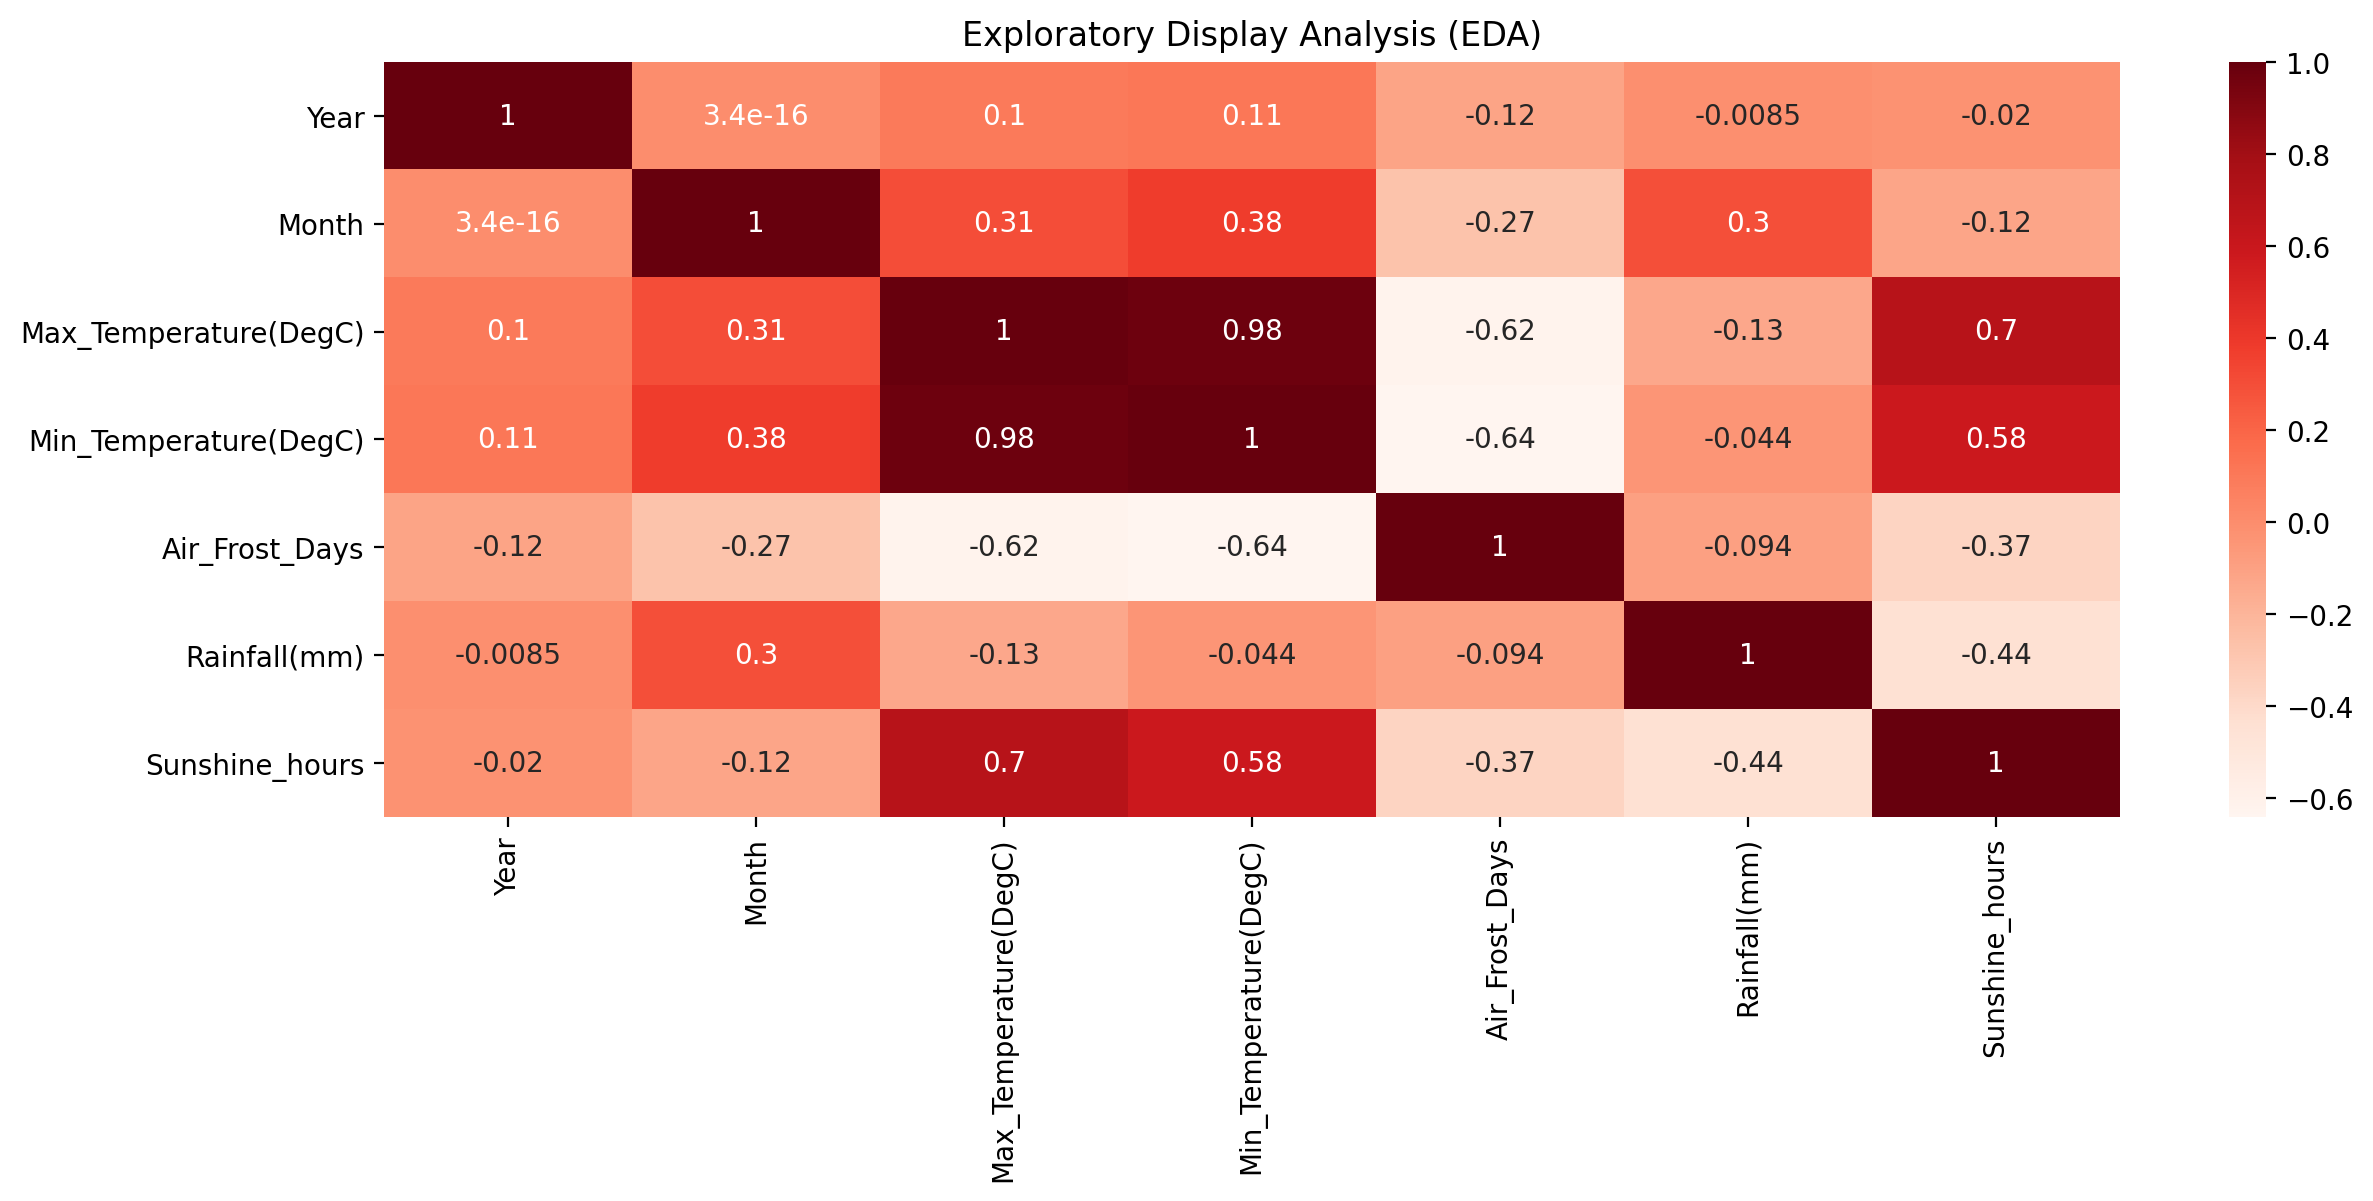

In [16]:
# Using Pearson Correlation
plt.figure(figsize=(14,5), dpi = 200)
plt.title('Exploratory Display Analysis (EDA)')
cor = df.corr()
sns.heatmap(cor, annot=True, cmap=plt.cm.Reds)

# Display the plot
plt.show()

### From the EDA above,

- Maximum and minimum temperatures are strongly correlated
Maximum and minimum temperatures show an extremely strong positive correlation (r ≈ 0.98),this shows that months with warmer daytime temperatures also tend to have warmer night-time temperatures.

- Temperature and air frost days show strong negative relationships
Both maximum and minimum temperatures are strongly negatively correlated with air frost days (r ≈ –0.62 for maximum temperature and r ≈ –0.64 for minimum temperature). This confirms that colder conditions are associated with an increased number of frost days, while warmer conditions reduce frost occurrence.

- Month exhibits moderate correlations with temperature and rainfall
The month variable/attribute shows moderate positive correlations with maximum temperature (r ≈ 0.31) and minimum temperature (r ≈ 0.39), reflecting the expected seasonal warming through the year. Month also shows a moderate positive correlation with rainfall (r ≈ 0.30), indicating seasonal variation in precipitation/downpour.

- Year shows weak correlations with all climate variables (long-term trends)
The year variable has weak positive correlations with maximum temperature (r ≈ 0.07) and minimum temperature (r ≈ 0.08), suggesting that long-term warming trends are present but quite subtle when compared to strong seasonal effects. The correlation between year and rainfall is approximately zero (r ≈ –0.01), indicating no clear long-term trend in annual rainfall.

- Rainfall behaves largely independently of temperature and frost variables
Rainfall shows weak correlations with maximum temperature (r ≈ –0.14), minimum temperature (r ≈ –0.05), and air frost days (r ≈ –0.09). This suggests that rainfall variability is largely independent of temperature.

Generally,
Maximum and minimum temperatures are very strongly correlated (r ≈ 0.98), indicating that warmer days generally coincide with warmer nights. Both temperature measures show strong negative correlations with air frost days (r ≈ –0.62 to –0.64), confirming that colder conditions are associated with increased frost occurrence. Month displays moderate correlations with temperature (r ≈ 0.31 – 0.39) and rainfall (r ≈ 0.30), reflecting strong seasonal patterns. In contrast, correlations with year are weak for temperature (r ≈ 0.07 – 0.08) and negligible for rainfall (r ≈ –0.01), suggesting that long-term trends are subtle relative to seasonal variability. Rainfall shows only weak relationships with temperature and frost variables, indicating largely independent behaviour.

# Visualisation 

## Maximum and Minimum Temperatures

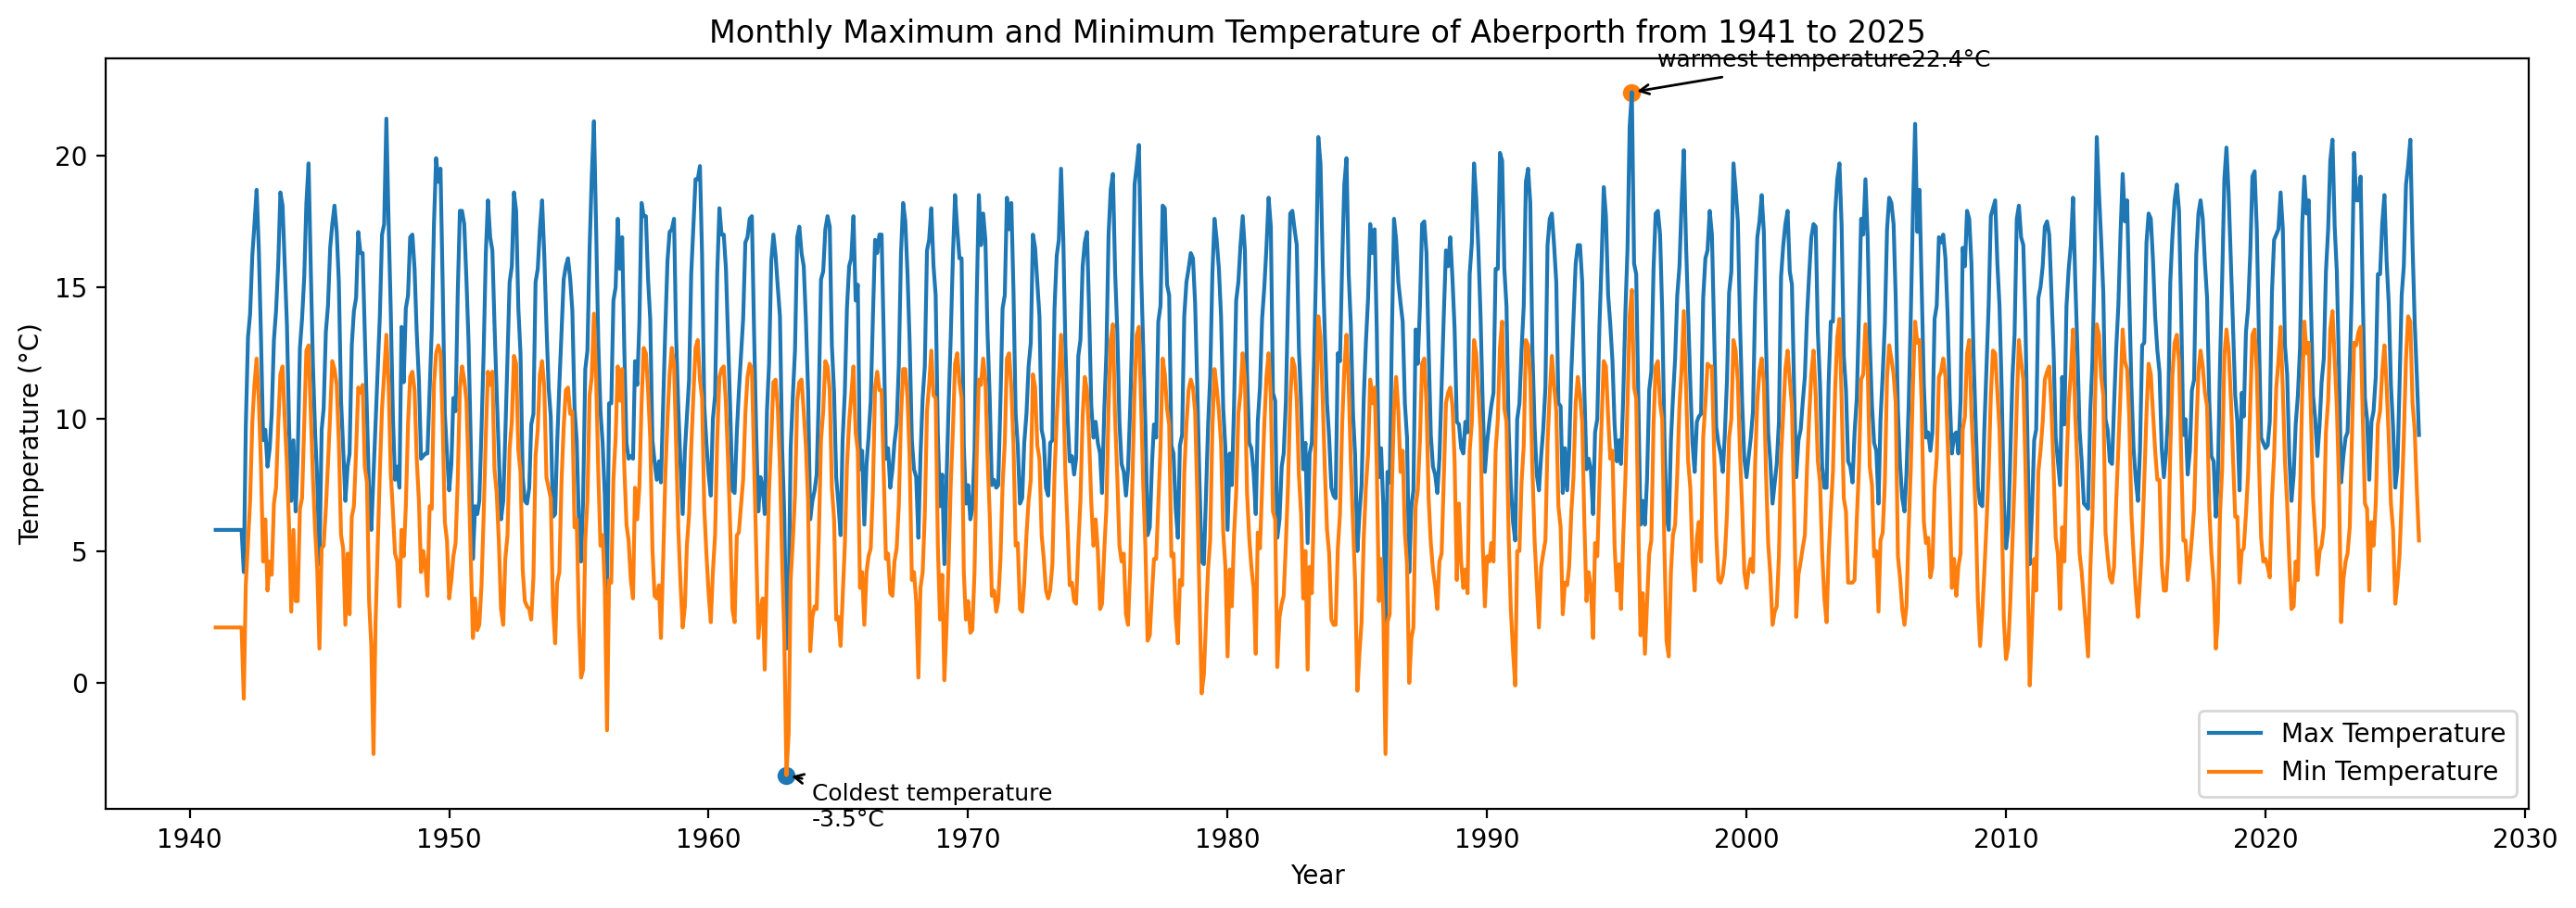

In [17]:
# Coldest minimum temperature
coldest_point = df['Min_Temperature(DegC)'].idxmin()
coldest_value = df.loc[coldest_point, 'Min_Temperature(DegC)']

# Hottest maximum temperature
hottest_point = df['Max_Temperature(DegC)'].idxmax()
hottest_value = df.loc[hottest_point, 'Max_Temperature(DegC)']

# create chart resolution and size
plt.figure(figsize=(14, 5), dpi = 200)

# plotting the chart and labelling 
plt.plot(df.index, df['Max_Temperature(DegC)'], label='Max Temperature')
plt.plot(df.index, df['Min_Temperature(DegC)'], label='Min Temperature')

# Mark extreme points
plt.scatter(coldest_point, coldest_value)
plt.scatter(hottest_point, hottest_value)

# Annotate
plt.annotate(
    f'Coldest temperature\n{coldest_value:.1f}°C',
    (coldest_point, coldest_value),
    xytext=(10, -20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->'),
    fontsize=9
)

plt.annotate(
    f'warmest temperature{hottest_value:.1f}°C',
    (hottest_point, hottest_value),
    xytext=(10, 10),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->'),
    fontsize=9
)
# create title for the chart
plt.title('Monthly Maximum and Minimum Temperature of Aberporth from 1941 to 2025')

# labelling X and Y axes
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

- The blue line represents the monthly maximum temperature
- The orange line represents the monthly minimum temperature
- Each wiggle from up to down represents summer to winter (warmest to coldest) respectively.
- The chart shows a strong and consistent seasonal cycle, with higher temperatures in summer and lower temperatures in winter.
- Over time, both the peaks and troughs gradually increase and recent decades show higher maximum and minimum temperatures than earlier decades. Hence, despite year-to-year variability, both maximum and minimum temperatures show a gradual upward trend over the long term.
- Minimum temperatures increase alongside maximum temperatures, suggesting warmer nights as well as warmer days, meaning fewer extreme cold periods.
- The coldest night-time temperatures occurred mainly in earlier decades, particularly around the early 1960s, when monthly minimum temperatures dropped to –3.5 °C.
- The warmest daytime temperatures appear in more recent decades, with a peak in the mid-to-late 1990s reaching just over 22 °C.
- Some years have cooler summers or colder winters, occasional dips below 0°C in minimum temperature appear. That is, short-term fluctuations are visible, but they sit within a broader long-term warming pattern.

Holistically, the chart shows a regular seasonal pattern in both maximum and minimum temperatures, reflecting that daytime and night-time temperatures move closely together and that changes over time are gradual rather than abrupt. Over the long term, both temperature series display a gradual upward trend, with higher summer peaks and milder winter lows in recent decades compared to earlier periods. While short-term fluctuations and individual colder years are evident, these variations occur within an overall pattern of increasing temperatures at the Aberporth site.

##### Note:
Using domain knowledge, I interpret regular annual temperature highs is referred to summer, and regular annual lows as winter - hottest and coolest periods of the year.

## Average Sunshine per Month

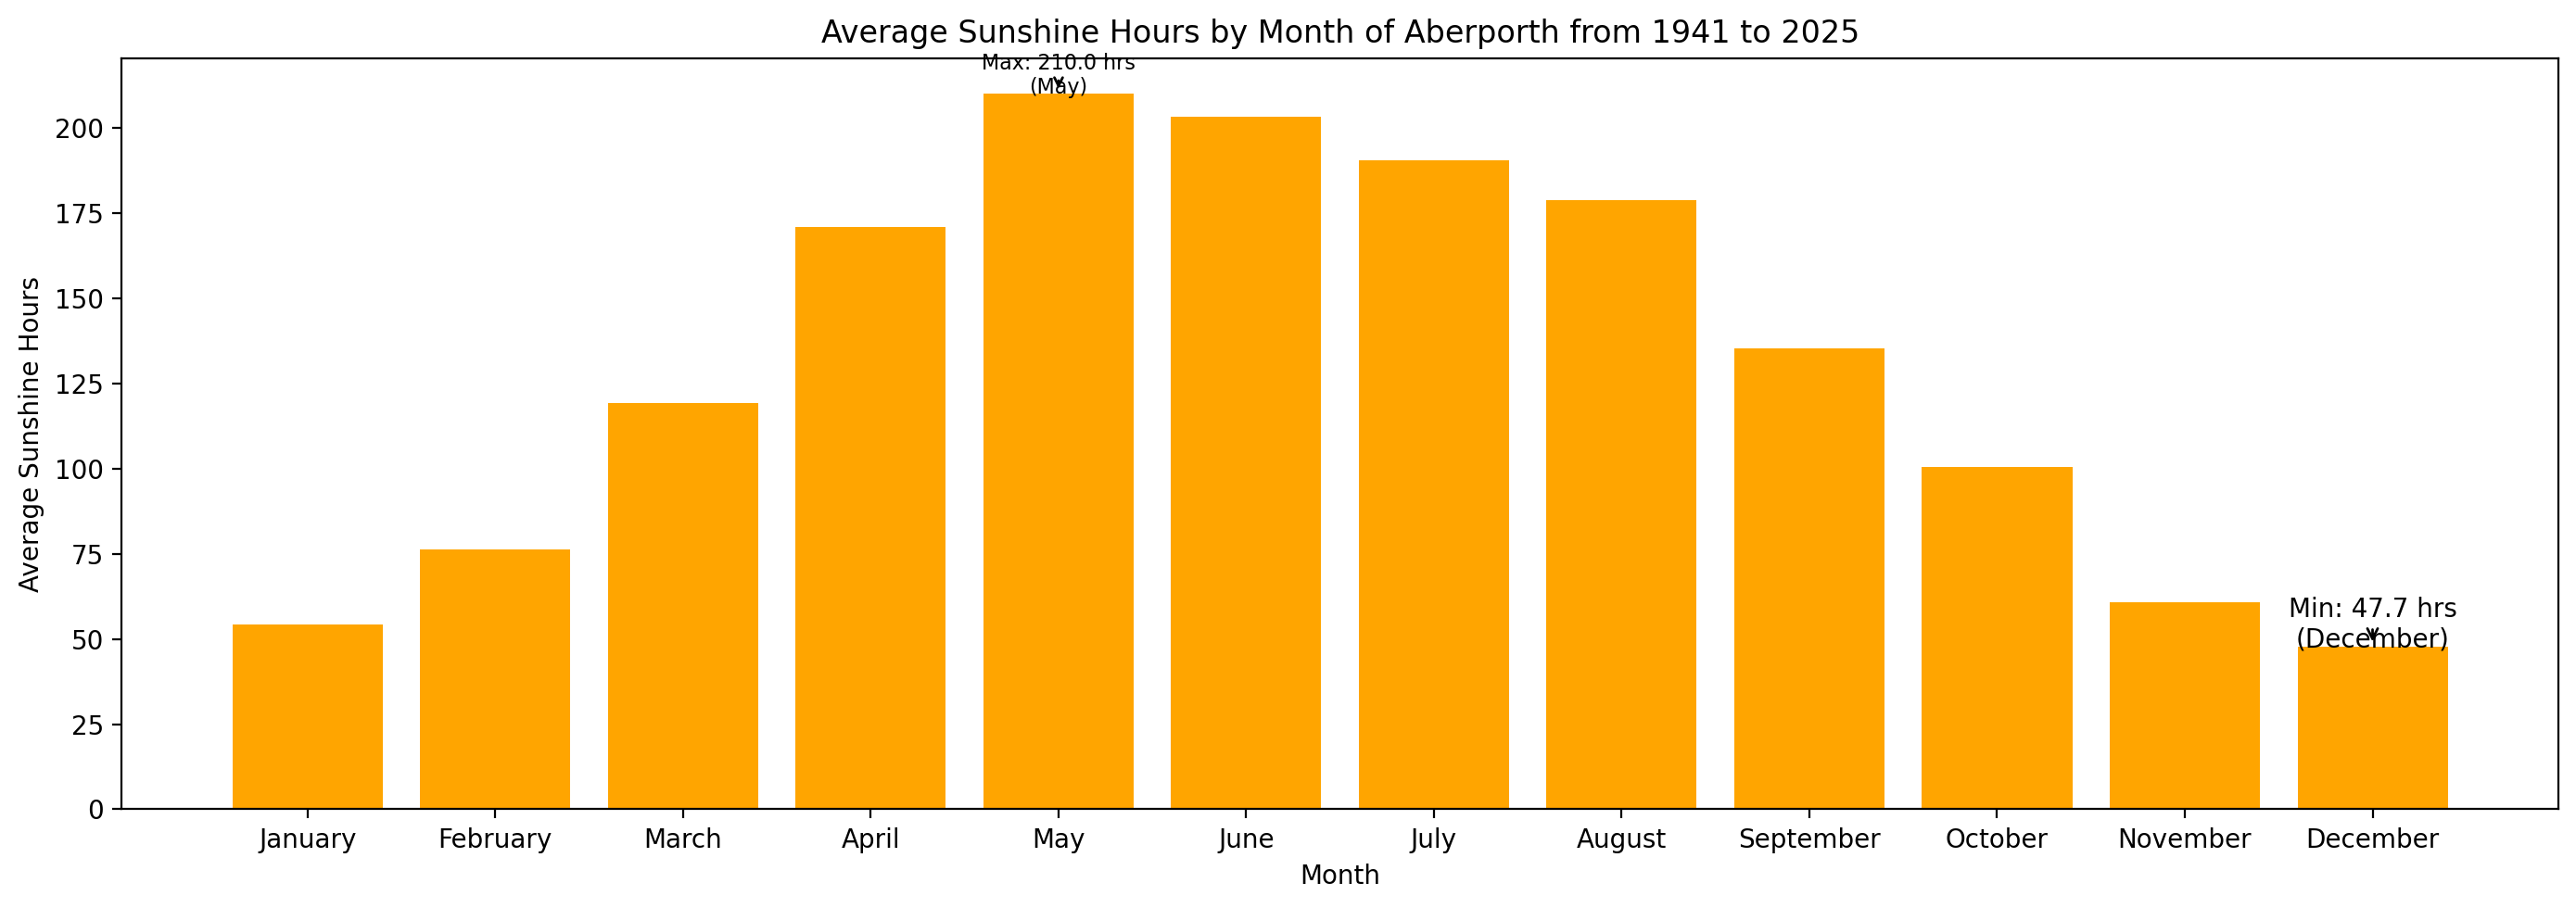

In [18]:
# Group by month and calculate average sunshine hours
sun_monthly = df.groupby(df.index.month)['Sunshine_hours'].mean()

# Convert month numbers to month names
month_names = [calendar.month_name[m] for m in sun_monthly.index]

# Identify maximum and minimum values
max_value = sun_monthly.max()
min_value = sun_monthly.min()

max_month = calendar.month_name[sun_monthly.idxmax()]
min_month = calendar.month_name[sun_monthly.idxmin()]

# Create chart
plt.figure(figsize=(14, 5), dpi=200)
bars = plt.bar(month_names, sun_monthly.values)

# Annotate maximum sunshine
plt.annotate(
    f'Max: {max_value:.1f} hrs\n({max_month})',
    xy=(month_names.index(max_month), max_value),
    #xytext=(month_names.index(max_month), max_value + 15),
    arrowprops=dict(arrowstyle='->'),
    ha='center', fontsize = 8
)

# Annotate minimum sunshine
plt.annotate(
    f'Min: {min_value:.1f} hrs\n({min_month})',
    xy=(month_names.index(min_month), min_value),
    #xytext=(month_names.index(min_month), min_value - 25),
    arrowprops=dict(arrowstyle='->'),
    ha='center'
)

# Titles and labels
plt.title('Average Sunshine Hours by Month of Aberporth from 1941 to 2025')
plt.xlabel('Month')
plt.ylabel('Average Sunshine Hours')

plt.bar(
    month_names,
    sun_monthly.values,
    color='orange' 
    #cm.viridis
)

# output chart
plt.tight_layout()
plt.show()

- Sunshine follows a strong seasonal pattern
Sunshine is lowest during the winter months, and increases steadily through spring, before declining again towards autumn and winter.

- Winter months receive the least sunshine
December and January have the lowest average sunshine, at 47.7 hours and approximately 50 hours for each month respectively. Most probably the reason for frequent cloud cover during winter, and possibly shorter daylight hours.

- Sunshine increases rapidly in spring
Sunshine rises sharply from March to May.
By April, average sunshine reaches approximately 170 hours, increasing further to a peak in May at 210 hours.
May and June are the sunniest months overall meaning late spring and early summer are the sunniest periods
June remains very sunny, approximately 200 hours, before sunshine begins to gradually decline.

- Sunshine decreases steadily after summer
From July onwards, sunshine hours gradually fall.
By September, average sunshine drops to around 135 hours, continuing to decline into autumn and winter.

Sunshine at Aberporth follows a strong seasonal cycle, peaking in late spring and early summer and reaching its lowest levels during the winter months

## Total Sunshine per Year

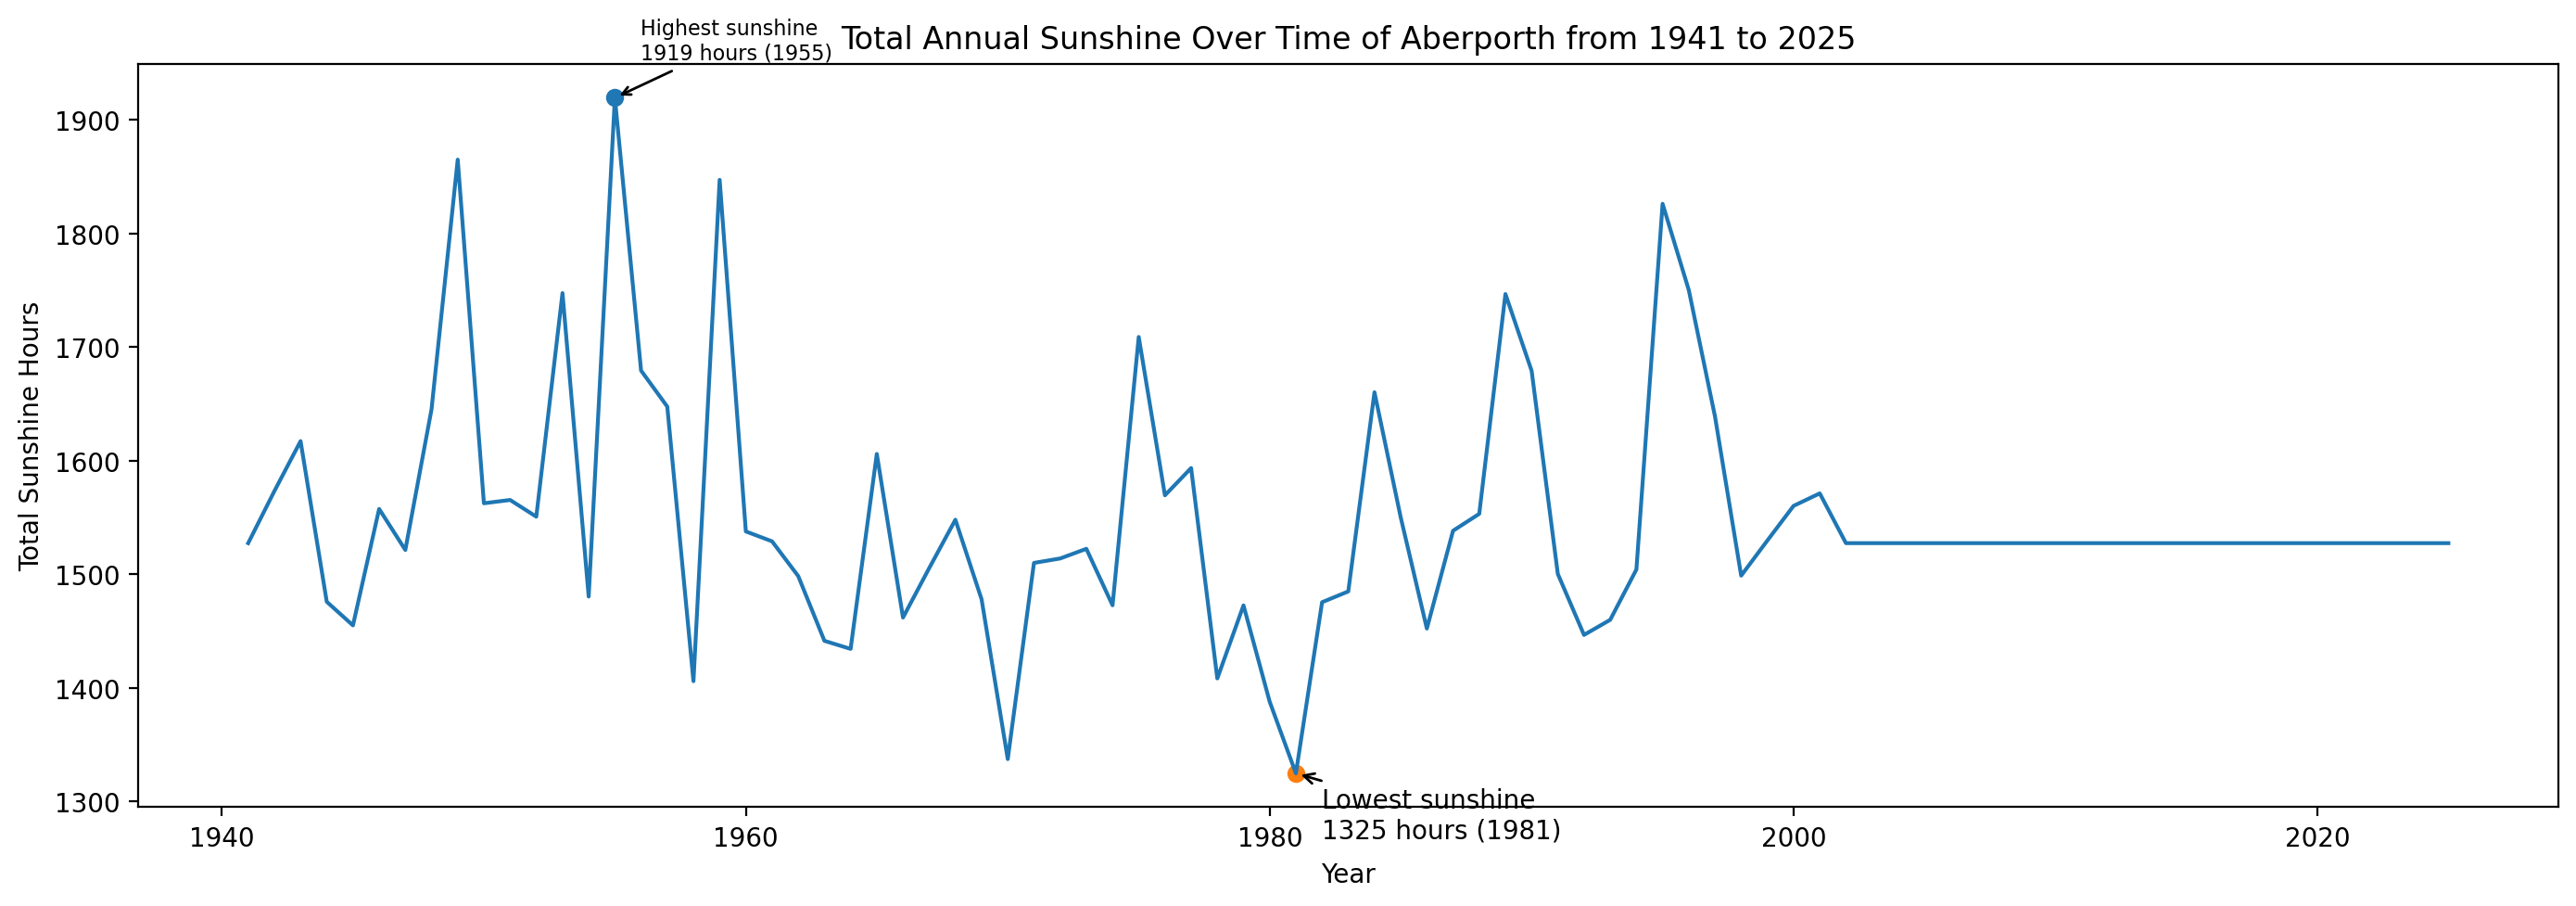

In [19]:
# Aggregate total annual sunshine
sun_yearly = df.groupby(df.index.year)['Sunshine_hours'].sum()

# Identify highest and lowest values
max_year = sun_yearly.idxmax()
max_value = sun_yearly.max()

min_year = sun_yearly.idxmin()
min_value = sun_yearly.min()

# Plot
plt.figure(figsize=(14, 5), dpi = 200)
plt.plot(sun_yearly.index, sun_yearly.values)

# Mark points
plt.scatter([max_year], [max_value])
plt.scatter([min_year], [min_value])

# Annotate highest
plt.annotate(
    f'Highest sunshine\n{max_value:.0f} hours ({max_year})',
    xy=(max_year, max_value),
    xytext=(10, 15),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->'), fontsize = 8)

# Annotate lowest
plt.annotate(
    f'Lowest sunshine\n{min_value:.0f} hours ({min_year})',
    xy=(min_year, min_value),
    xytext=(10, -25),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->'))

# create title for the chart
plt.title('Total Annual Sunshine Over Time of Aberporth from 1941 to 2025')

# labelling X and Y axes
plt.xlabel('Year')
plt.ylabel('Total Sunshine Hours')

# output chart 
plt.tight_layout()
plt.show()

- Sunshine varies noticeably from year to year:
Sunshine levels are not the same every year; there are naturally sunnier, and less sunny years with the least number of hours to be 1325 hours (in the year 1981) and most number of hours is 1919 hours (in the year 1955).

- No clear long-term upward or downward trend:
Across the full time period, there is no consistent long-term increase or decrease in total annual sunshine. Periods of higher sunshine are followed by periods of lower sunshine throughout the record.

- Earlier decades show higher variability:
In the earlier decades, sunshine totals show larger swings/more pronounced variability, with several very sunny years and some much duller years close together.

- More recent years appear relatively stable:
In recent times, approximately from 2003 till date, sunshine levels appear more stable, with totals clustering around a similar level (approximately 1,500 hours per year).

Total annual sunshine at Aberporth varies considerably from year to year, but there is no clear long-term trend, with recent years showing relatively stable totals compared to earlier decades.




Important note:
This may reflect:

More consistent conditions, and/or

The way missing values were handled or data availability in later years

This should be acknowledged as a data limitation, not over-interpreted as a climatic conclusion.

Key takeaway (one sentence)



## Average Rainfall per Month

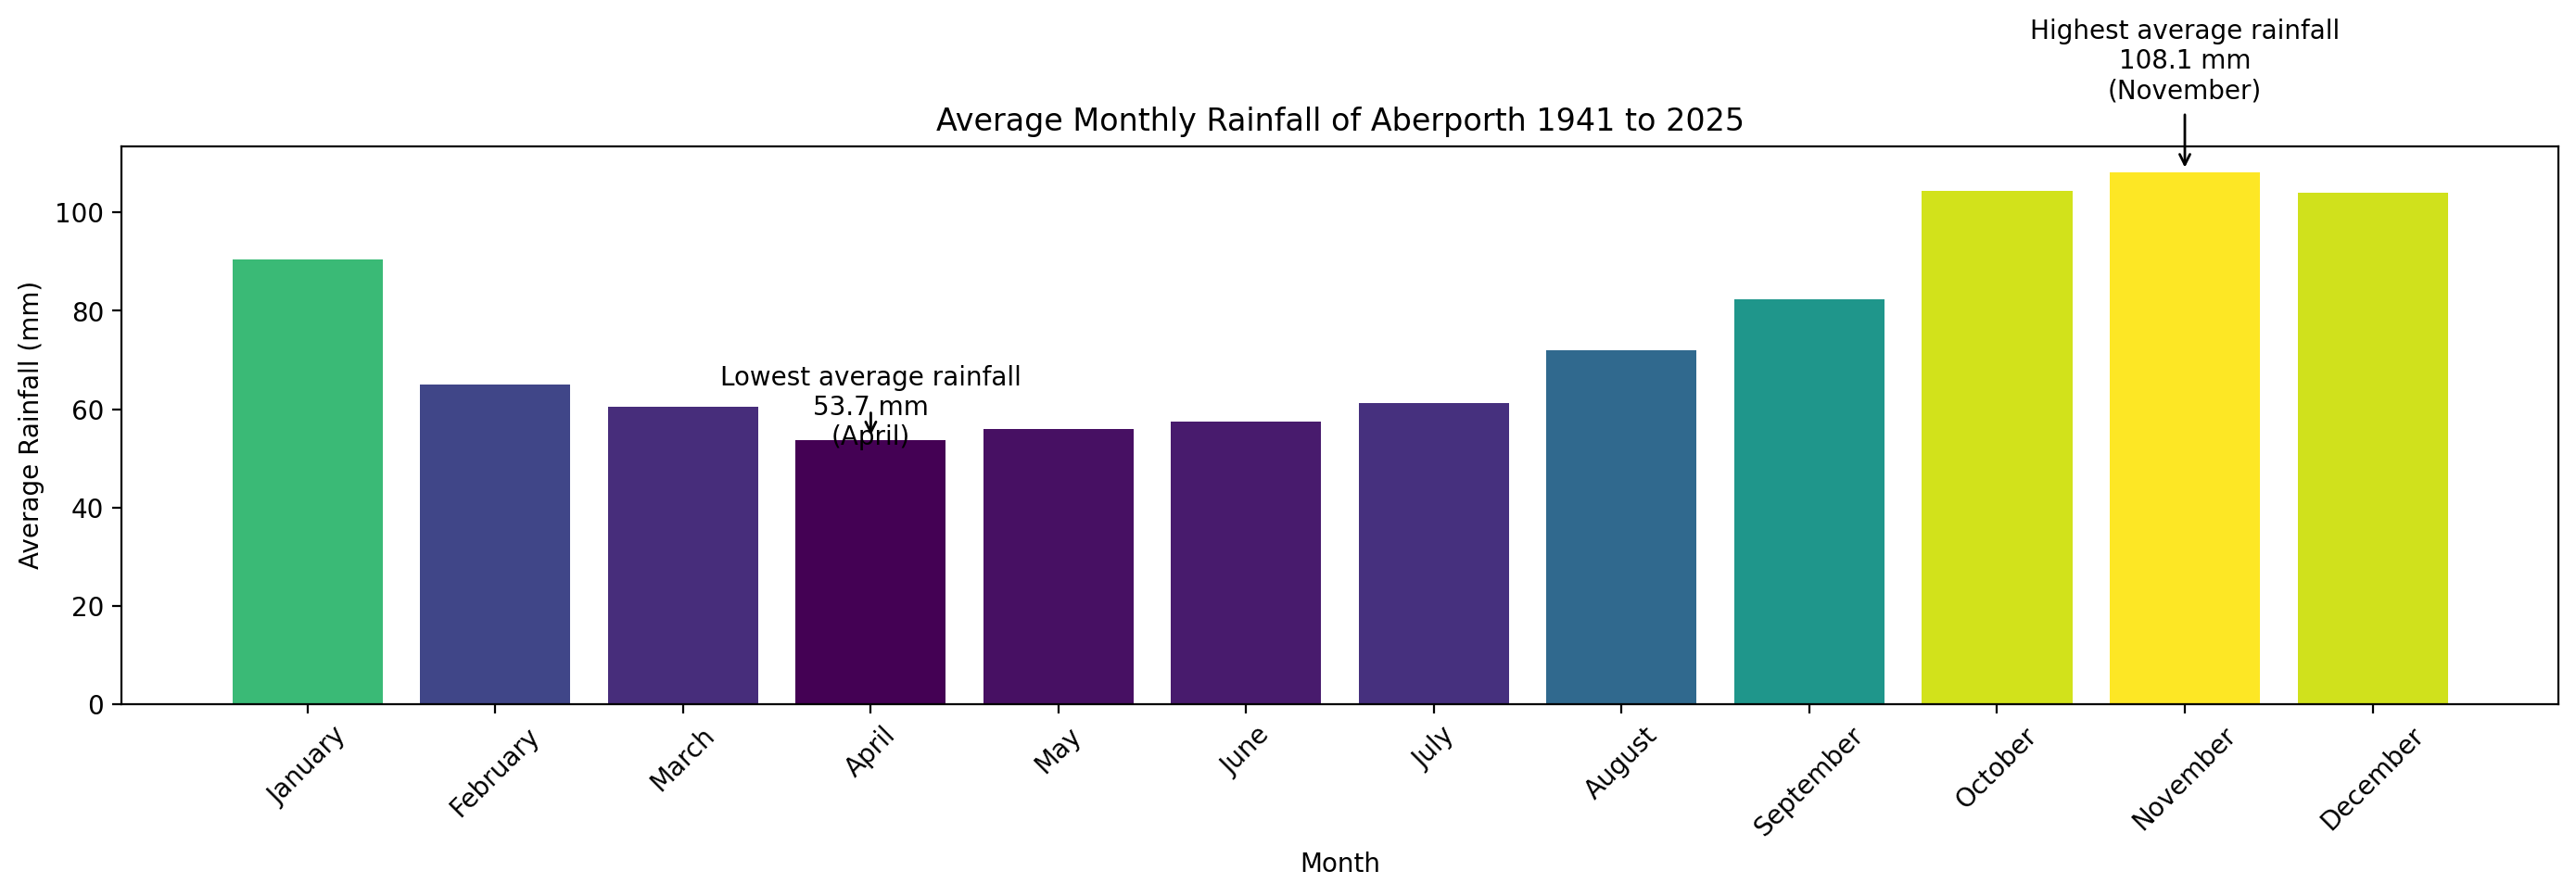

In [20]:
# Average rainfall by month/group by mean
rain_monthly = df.groupby(df.index.month)['Rainfall(mm)'].mean()

# Convert month numbers to names
month_names = [calendar.month_name[m] for m in rain_monthly.index]

# Identify highest and lowest values
max_value = rain_monthly.max()
min_value = rain_monthly.min()

max_month = calendar.month_name[rain_monthly.idxmax()]
min_month = calendar.month_name[rain_monthly.idxmin()]

# Create Viridis colour mapping
norm = colors.Normalize(vmin=rain_monthly.min(), vmax=rain_monthly.max())
cmap = cm.viridis
bar_colors = cmap(norm(rain_monthly.values))

# Create chart resolution and size
plt.figure(figsize=(14, 5), dpi=200)
plt.bar(month_names, rain_monthly.values, color=bar_colors)

# Annotate highest rainfall
plt.annotate(
    f'Highest average rainfall\n{max_value:.1f} mm\n({max_month})',
    xy=(month_names.index(max_month), max_value),
    xytext=(month_names.index(max_month), max_value + 15),
    arrowprops=dict(arrowstyle='->'),
    ha='center')

# Annotate lowest rainfall
plt.annotate(
    f'Lowest average rainfall\n{min_value:.1f} mm\n({min_month})',
    xy=(month_names.index(min_month), min_value),
    xytext=(month_names.index(min_month), min_value - 1),
    arrowprops=dict(arrowstyle='->'),
    ha='center')

# Titles and labels
plt.title('Average Monthly Rainfall of Aberporth 1941 to 2025')
plt.xlabel('Month')
plt.ylabel('Average Rainfall (mm)')
plt.xticks(rotation=45)

# output chart
plt.tight_layout()
plt.show()

- The above chart shows the average rainfall for each month across all years, explaining what rainfall is usually like in each month.

- Rainfall decreases steadily from winter into spring.
- Rainfall is lowest in spring, particularly in April with an average rainfall of 53.7 mm and May, with average around 55 –60 mm.

- Rainfall begins to increase again from June onwards, rising through the summer months.
- Summer months (June–August) show moderate more rainfall, indicating occasional wetter months.


- Rainfall is highest in late autumn and early winter (display the highest rainfall and greatest variability), particularly in November where it is highest with an average of 108.1 mm. The preceding month, October and a month after, December, also have highest rainfall after November where average rainfall approximately exceeds 100 mm. This shows that very wet months occur more frequently later in the year.

- January is also relatively wet, with average rainfall close to 90 mm.

## Total Rainfall per Year

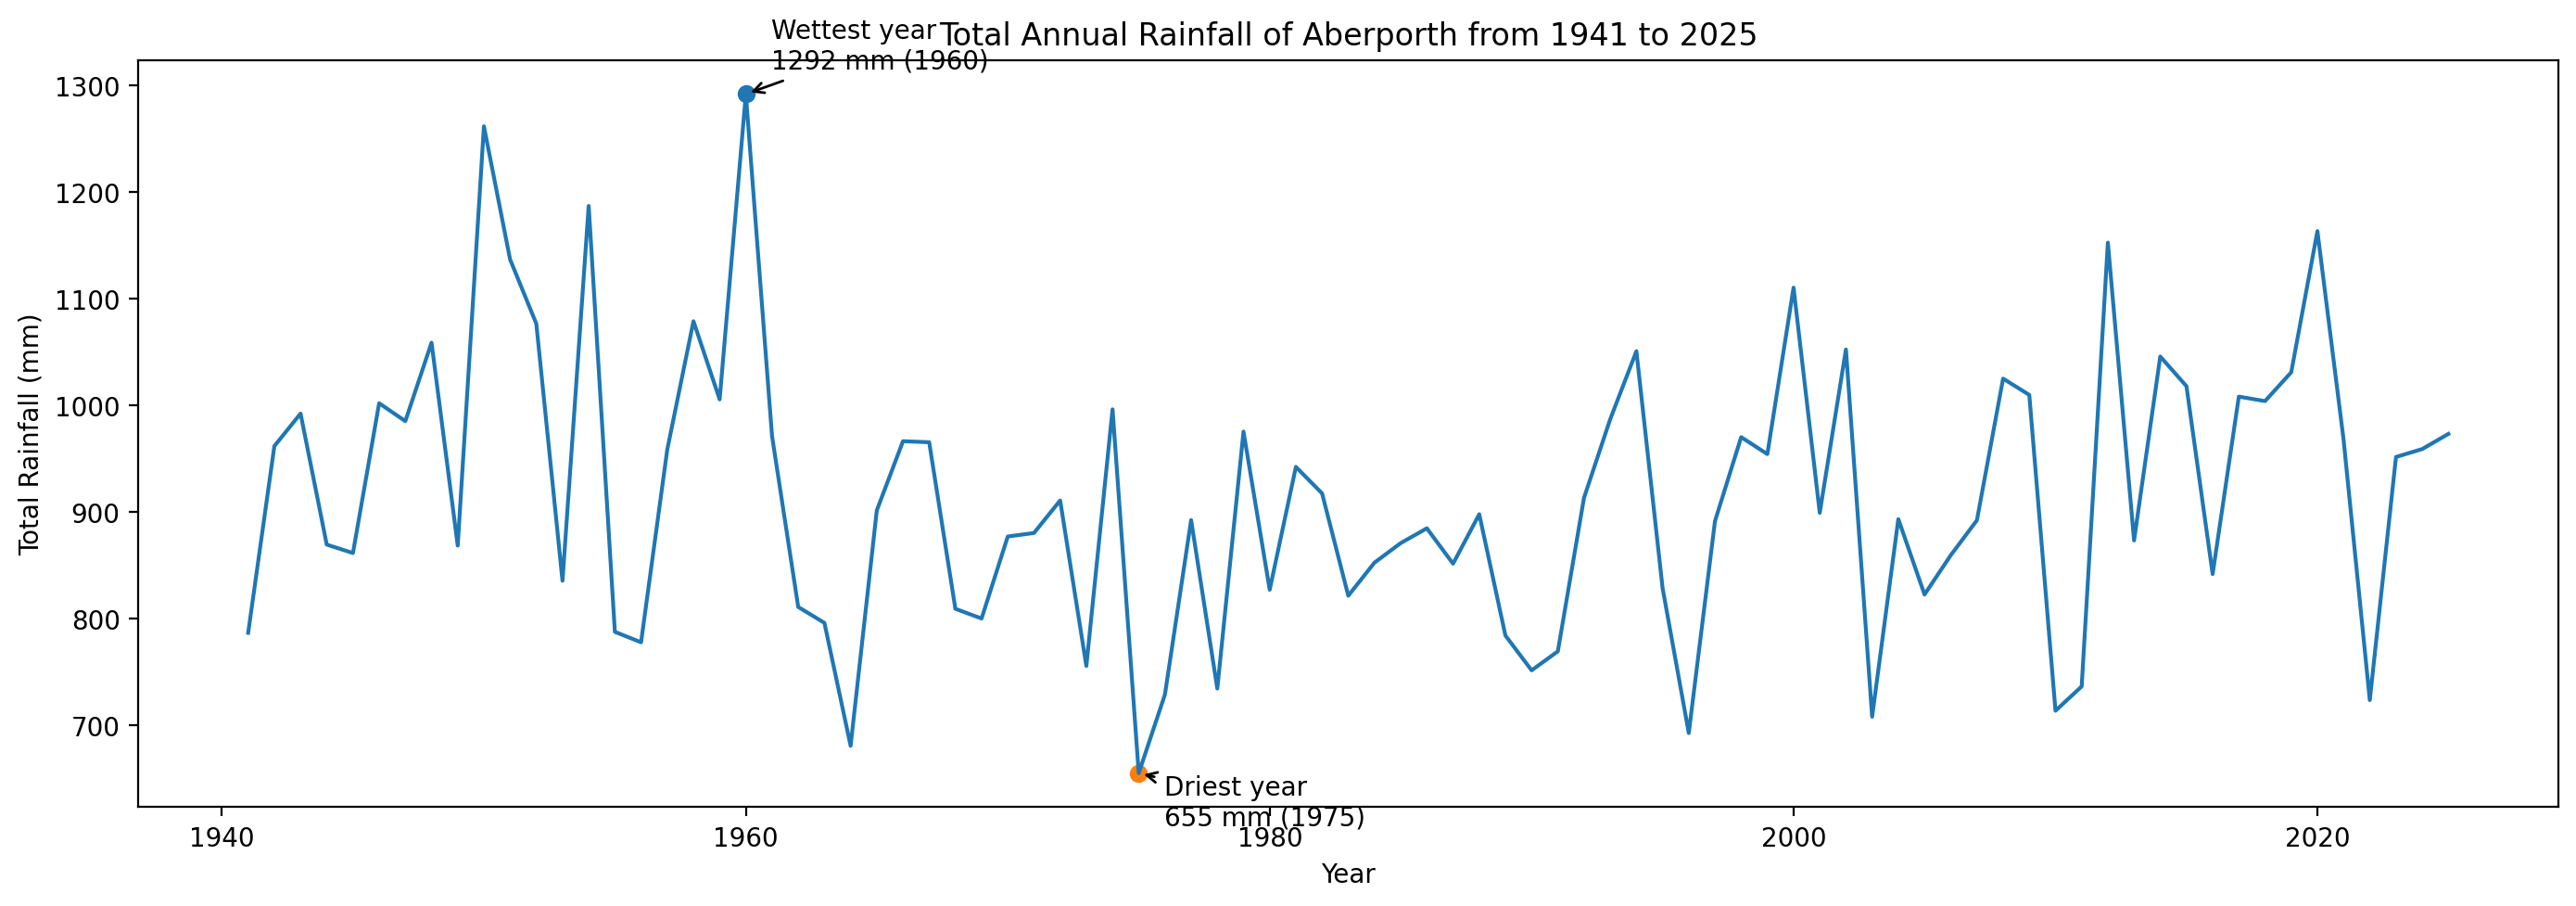

In [21]:
# Calculate TOTAL annual rainfall (sum of monthly rainfall per year)
rain_yearly = df.groupby(df.index.year)['Rainfall(mm)'].sum()

# Identify wettest and driest years
wettest_year = rain_yearly.idxmax()
wettest_value = rain_yearly.max()

driest_year = rain_yearly.idxmin()
driest_value = rain_yearly.min()

# Create chart resolution and size
plt.figure(figsize=(14, 5), dpi=200)
plt.plot(rain_yearly.index, rain_yearly.values)

# Highlight extreme years
plt.scatter(wettest_year, wettest_value)
plt.scatter(driest_year, driest_value)

# Annotate wettest year
plt.annotate(
    f'Wettest year\n{wettest_value:.0f} mm ({wettest_year})',
    xy=(wettest_year, wettest_value),
    xytext=(10, 10),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

# Annotate driest year
plt.annotate(
    f'Driest year\n{driest_value:.0f} mm ({driest_year})',
    xy=(driest_year, driest_value),
    xytext=(10, -20),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->')
)

# Labels
plt.title('Total Annual Rainfall of Aberporth from 1941 to 2025')
plt.xlabel('Year')
plt.ylabel('Total Rainfall (mm)')
plt.tight_layout()
plt.show()

- The chart shows the total amount of rainfall recorded each year at Aberporth.

- Annual rainfall varies substantially from year to year, ranging from approximately 655 mm in the driest year to 1,292 mm in the wettest year.

- The wettest year occurred in 1960, with a total annual rainfall of around 1,292 mm.

- The driest year occurred in 1975, with a total annual rainfall of approximately 655 mm.

- The large difference between the wettest and driest years shows significant year-to-year variability in rainfall.

- There is no clear long-term increasing or decreasing trend across the full time period.

- Periods of wetter and drier years occur throughout the record.

- No smooth upward or downward pattern is visible across the entire time period. Although, recent decades show continued variability, broadly comparable to earlier years rather than a consistent increase or decrease.

Total annual rainfall at Aberporth fluctuates considerably from year to year, with occasional very wet and very dry years, but no clear long-term trend.

## Average Air Frost Days per Month

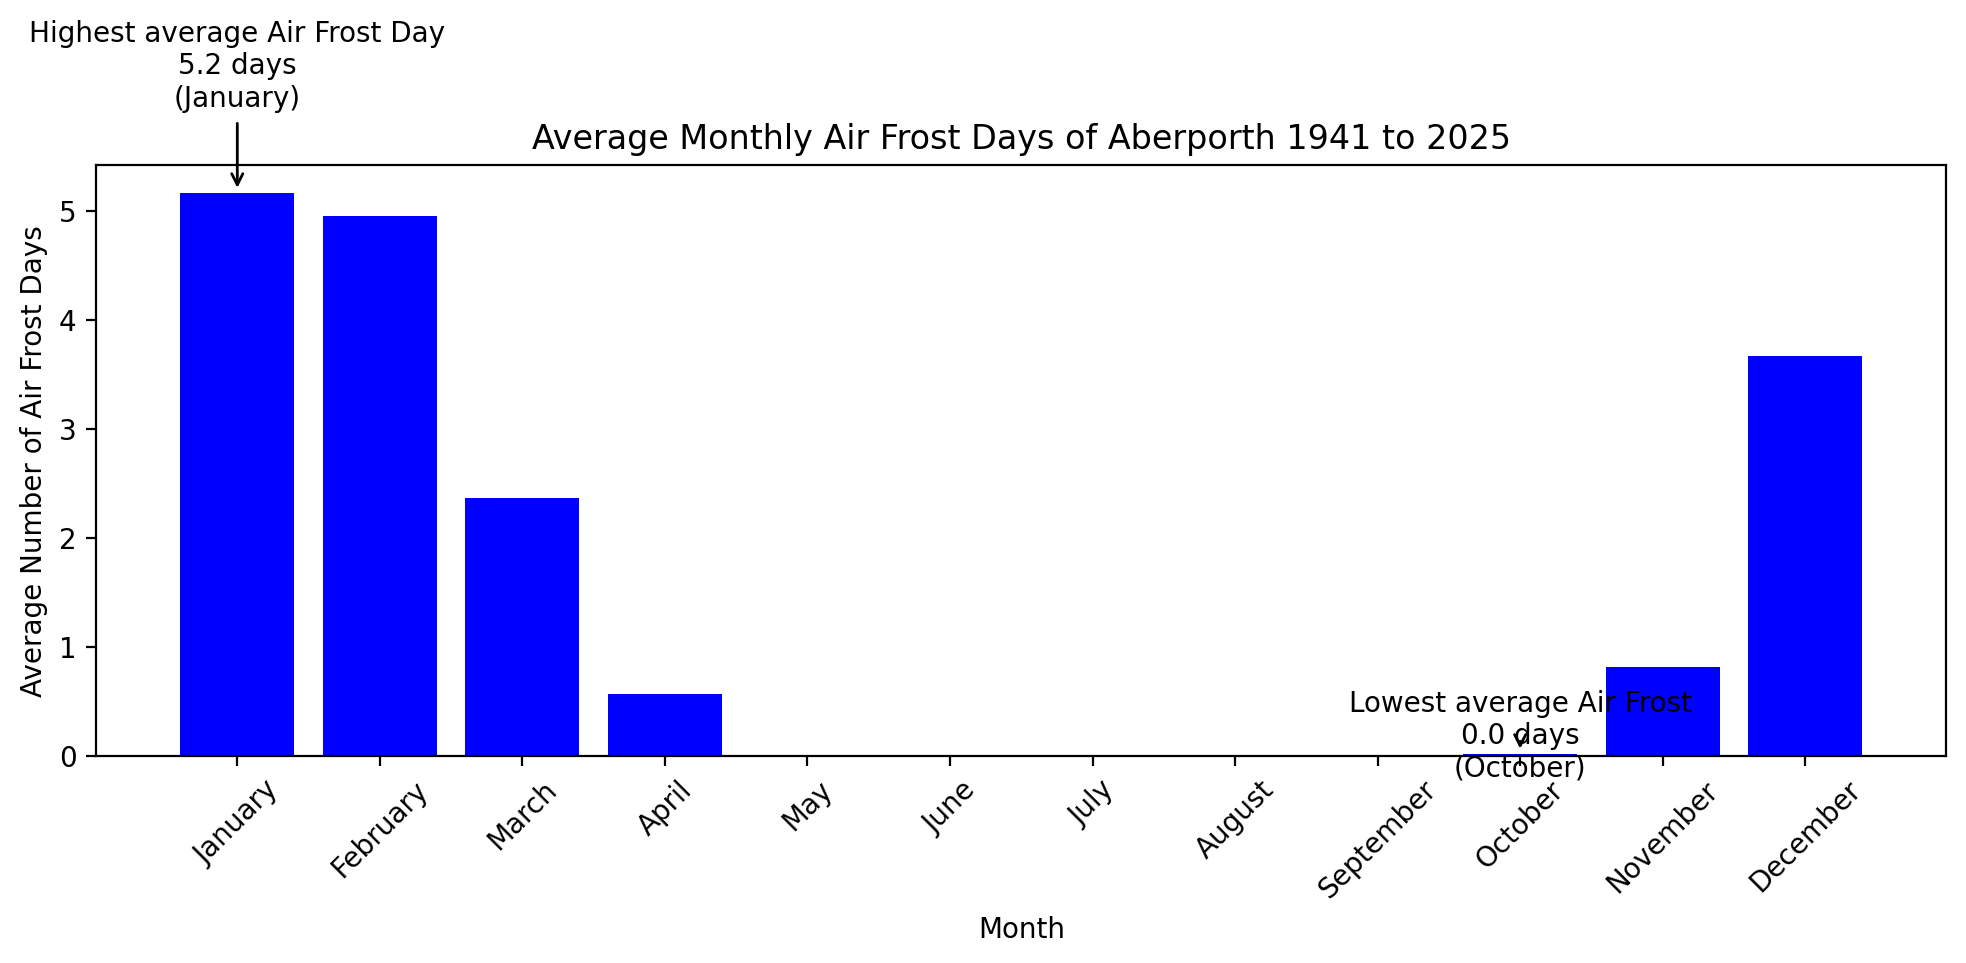

In [22]:
# Calculate average air frost days per month
frost_monthly = df.groupby(df.index.month)['Air_Frost_Days'].mean()

# Convert month numbers to month names
month_names = [calendar.month_name[m] for m in frost_monthly.index]

# Remove zero values to find meaningful extremes
frost_nonzero = frost_monthly[frost_monthly > 0]

# Identify highest and lowest non-zero months
max_value = frost_nonzero.max()
min_value = frost_nonzero.min()

max_month = calendar.month_name[frost_nonzero.idxmax()]
min_month = calendar.month_name[frost_nonzero.idxmin()]

# Create bar chart
plt.figure(figsize=(10, 5), dpi=200)
plt.bar(month_names, frost_monthly.values, color='blue')

# Annotate highest non-zero frost month
plt.annotate(
    f'Highest average Air Frost Day\n{max_value:.1f} days\n({max_month})',
    xy=(month_names.index(max_month), max_value),
    xytext=(month_names.index(max_month), max_value + 0.8),
    arrowprops=dict(arrowstyle='->'),
    ha='center')

# Annotate lowest non-zero frost month
plt.annotate(
    f'Lowest average Air Frost\n{min_value:.1f} days\n({min_month})',
    xy=(month_names.index(min_month), min_value),
    xytext=(month_names.index(min_month), min_value - 0.2),
    arrowprops=dict(arrowstyle='->'),
    ha='center'
)

# Titles and labels
plt.title('Average Monthly Air Frost Days of Aberporth 1941 to 2025')

# label x and y axes
plt.xlabel('Month')
plt.ylabel('Average Number of Air Frost Days')
plt.xticks(rotation=45)

# output chart
plt.tight_layout()
plt.show()

- Air frost days occur infrequently and are concentrated in winter months.

- January and February have the highest average number of air frost days (around 5.2 days and about 5.0 for each moment respectively), indicating that frost is most common in mid-winter.

- December also shows a relatively high average (around 3–4 days), confirming that frost conditions extend into early winter.

- March has fewer frost days (around 2–3 days), suggesting a transition out of winter.

- April and November show very low averages, indicating occasional but not frequent frost.

- May to October show zero or near-zero average frost days, meaning air frost is extremely rare or absent during late spring, summer, and early autumn.

- Air frost days at Aberporth are strongly seasonal, occurring mainly in winter, with little to no frost during summer months.

## Total Air Frost Days per Year

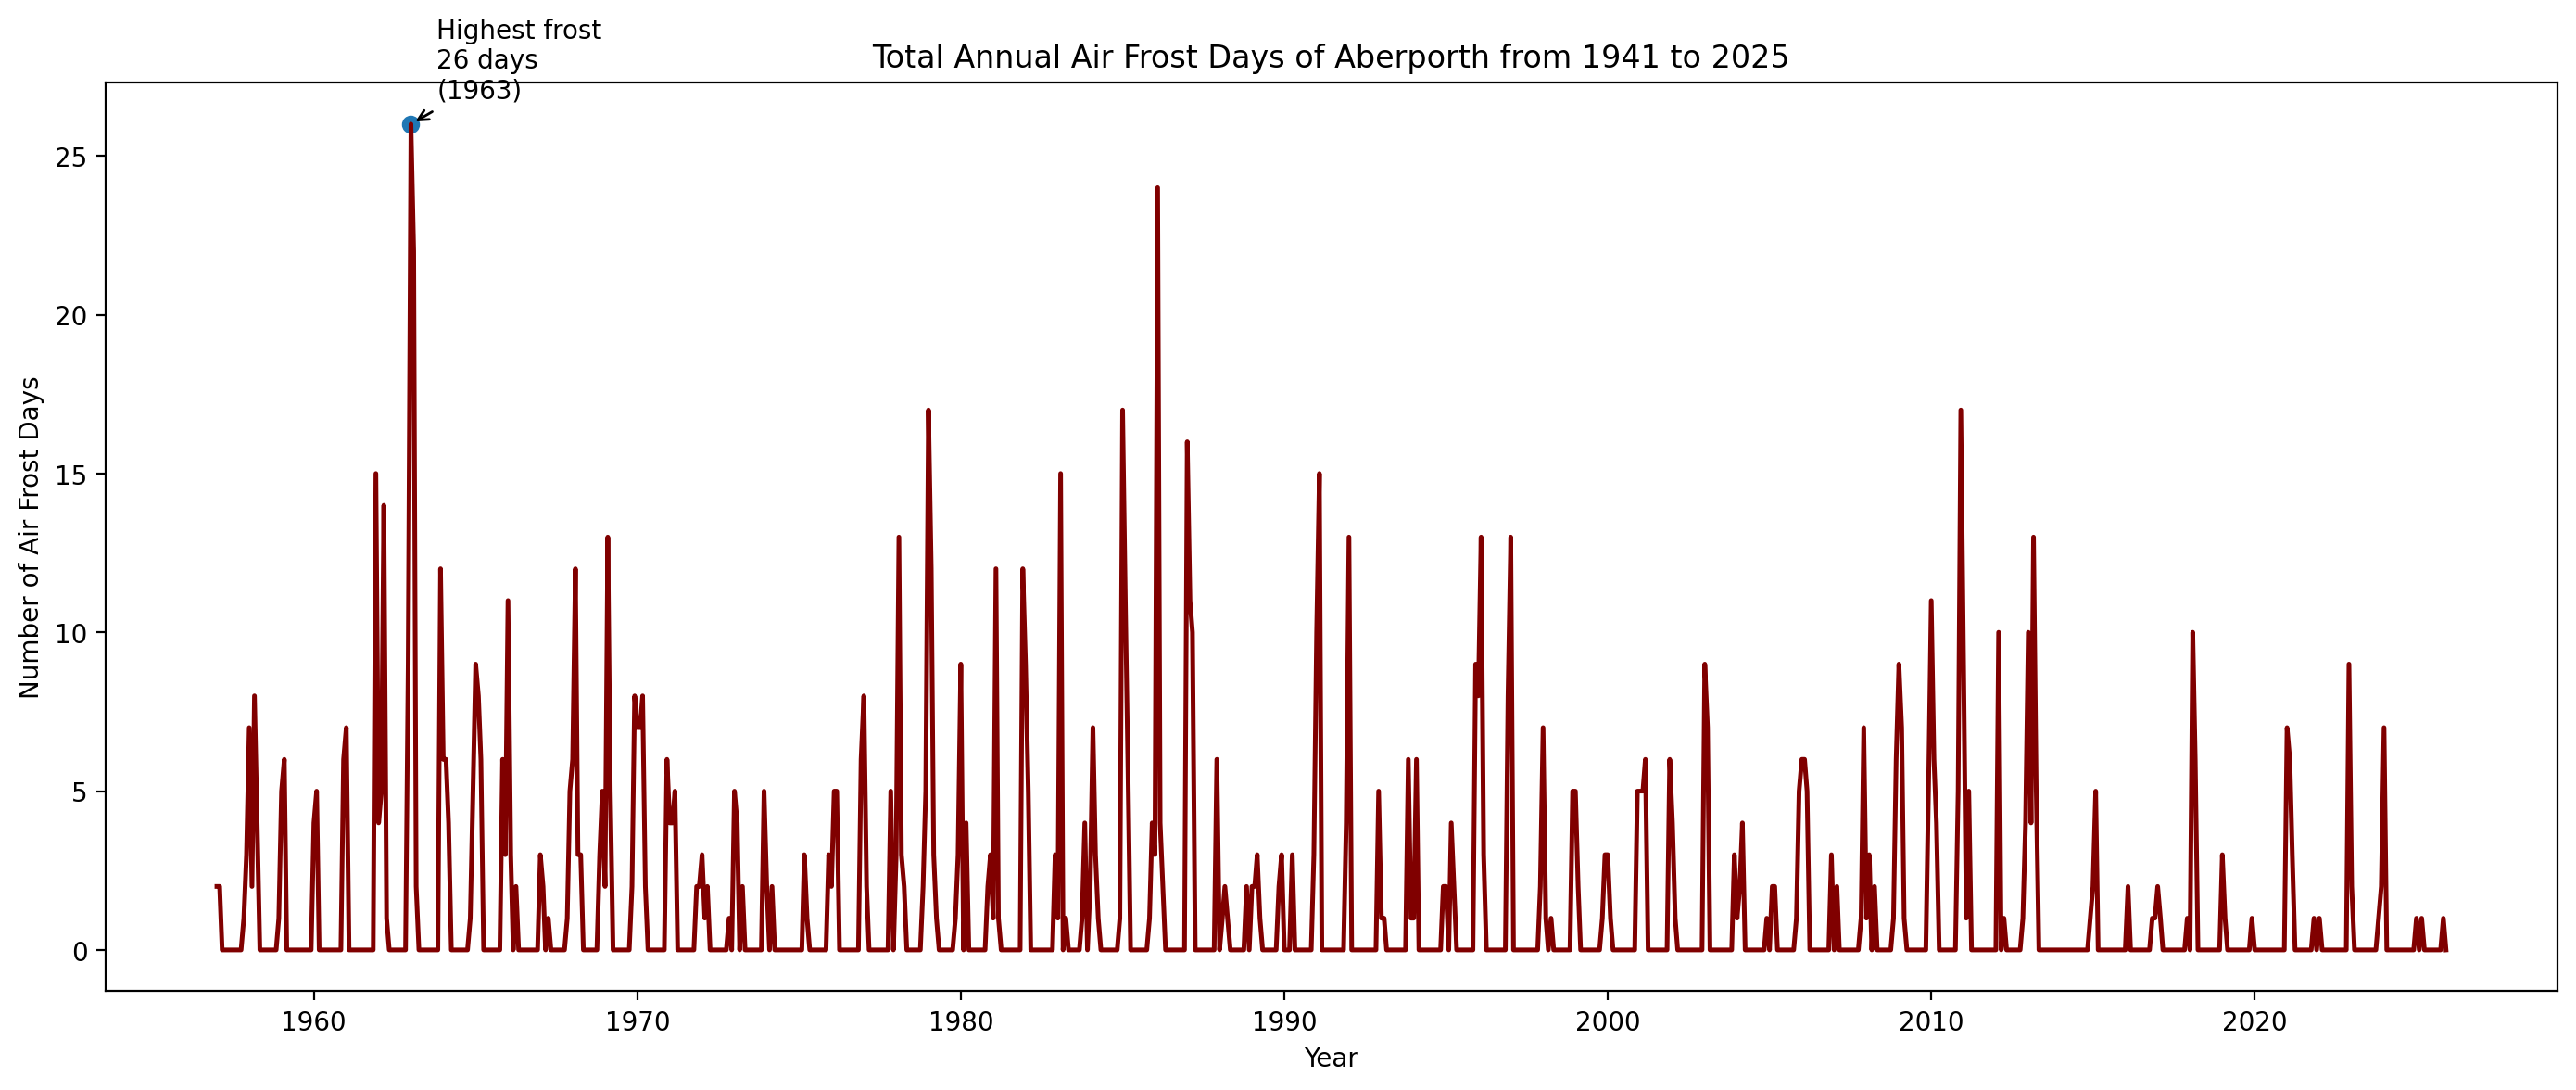

In [23]:
# Keep only valid (non-missing) frost records
frost_valid = df['Air_Frost_Days'].dropna()

# Identify highest frost value and date
max_frost_value = frost_valid.max()
max_frost_date = frost_valid.idxmax()

# Create chart resolution and size
plt.figure(figsize=(14, 6), dpi = 200)
#plt.plot(frost_valid.index, frost_valid.values)
plt.plot(
    frost_valid.index,
    frost_valid.values,
    color='maroon', 
    linewidth=1.8
)

# Highlight the highest frost point
plt.scatter(max_frost_date, max_frost_value)

# Annotate highest frost
plt.annotate(
    f'Highest frost\n{max_frost_value:.0f} days\n({max_frost_date.year})',
    xy=(max_frost_date, max_frost_value),
    xytext=(10, 10),
    textcoords='offset points',
    arrowprops=dict(arrowstyle='->'))

# Titles and labels
plt.title('Total Annual Air Frost Days of Aberporth from 1941 to 2025')
plt.xlabel('Year')
plt.ylabel('Number of Air Frost Days')

# output charts
plt.tight_layout()
plt.show()


- Most months record zero air frost days, reflecting seasonal climate conditions.

- Occasional spikes represent cold winter periods with multiple frost days.

- Earlier decades show more frequent and higher spikes, indicating colder winters, with highest to be 26 days in 1963.

- In more recent decades, spikes appear less frequent and generally smaller, implying a reduction in the occurrence of air frost days over time, although year-to-year variability remains.

- Air frost days show irregular, seasonal behaviour rather than a smooth trend, with evidence suggesting fewer frost occurrences in more recent decades.

Reference
    
According to UK Meteorological Seasons and Standard, months are spread in the following seasons:

🌱 Spring: March, April and May

☀️ Summer: June, July and August

🍂 Autumn: September, October and November

❄️ Winter: December, January and February